# RQ2 - Pain-management strategies

### Research question

**What pain-management strategies are reported by adults with high-impact chronic pain (HICP)?**

This is a descriptive question. I am not testing whether one strategy is better than another or whether any strategy causes better outcomes.

In this notebook I will:
- describe how commonly each pain-management strategy is reported
- keep the valid denominator visible for each strategy
- look at the broader pattern of pharmacological vs non-pharmacological strategy use

NOTE: The analysis is restricted to adults classified as having HICP

## Setup

-> NHIS data loaded, recreate the chronic-pain / HICP flags used in the previous notebooks, and keep only the HICP group for this analysis.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src.hicp import (flag_chronic_pain, flag_hicp, flag_cohort)

df = pd.read_csv("../data/raw/adult25csv/adult25.csv",low_memory=False)

In [2]:
df["chronic_pain"] = flag_chronic_pain(df)
df["hicp"] = flag_hicp(df)

In [3]:
cohort = flag_cohort(df)

analysis_df = df.loc[cohort].copy()

hicp_df = analysis_df.loc[analysis_df["hicp"]].copy()

In [4]:
hicp_df.shape

(1956, 579)

## RQ2 — Pain-management strategies

-> Now that I have the HICP group, I want to see which pain-management strategies people report using.

-> The NHIS asks about **11 different approaches** used in the past 3 months. People can report more than one, so these percentages do not need to add up to 100%.

-> Before calculating anything, I first check how these variables are coded and whether there are missing or special responses.

In [5]:
pain_management_vars = {
    "PAIOTCMEDS_A": "Over-the-counter medication (aspirin, Tylenol, Advil, or Aleve)",
    "PAIOPIOID_A": "Opioids (codeine, hydrocodone, morphine, oxycodone, OxyContin, Percocet, and Percodan)",
    "PAIPRSMEDS_A": "Prescribed pain reliever",
    "PAIPHYSTPY_A": "Physical therapy",
    "PAICHIRO_A": "Chiropractic care",
    "PAITALKTPY_A": "Talk therapy (such as CBT)",
    "PAIYOGA_A": "Yoga, Tai Chi, Qi Gong",
    "PAIEXRCISE_A": "Exercise such as walking, swimming, bike riding, stretching, strength training",
    "PAIMASSAGE_A": "Massage",
    "PAIMEDITAT_A": "Meditation or other relaxation techniques",
    "PAIMOTHER_A": "Other approaches"
}

In [6]:
for var, label in pain_management_vars.items():
    print(f"\n{label} ({var})")
    print(hicp_df[var].value_counts(dropna=False).sort_index())


Over-the-counter medication (aspirin, Tylenol, Advil, or Aleve) (PAIOTCMEDS_A)
PAIOTCMEDS_A
1.0    1517
2.0     436
8.0       3
Name: count, dtype: int64

Opioids (codeine, hydrocodone, morphine, oxycodone, OxyContin, Percocet, and Percodan) (PAIOPIOID_A)
PAIOPIOID_A
1.0     641
2.0    1304
7.0       3
8.0       4
9.0       4
Name: count, dtype: int64

Prescribed pain reliever (PAIPRSMEDS_A)
PAIPRSMEDS_A
1.0     654
2.0    1281
7.0       1
8.0       4
9.0      16
Name: count, dtype: int64

Physical therapy (PAIPHYSTPY_A)
PAIPHYSTPY_A
1.0     621
2.0    1330
8.0       5
Name: count, dtype: int64

Chiropractic care (PAICHIRO_A)
PAICHIRO_A
1.0     215
2.0    1735
8.0       5
9.0       1
Name: count, dtype: int64

Talk therapy (such as CBT) (PAITALKTPY_A)
PAITALKTPY_A
1.0     134
2.0    1814
7.0       1
8.0       5
9.0       2
Name: count, dtype: int64

Yoga, Tai Chi, Qi Gong (PAIYOGA_A)
PAIYOGA_A
1.0     158
2.0    1792
8.0       6
Name: count, dtype: int64

Exercise such as walking, swi

In [7]:
response_audit = []

for var, label in pain_management_vars.items():
    s = hicp_df[var]

    response_audit.append({
        "Strategy": label,
        "Yes": (s == 1).sum(),
        "No": (s == 2).sum(),
        "Special responses": s.isin([7, 8, 9]).sum(),
        "Missing": s.isna().sum(),
        "Valid n": s.isin([1, 2]).sum()
    })

response_audit = pd.DataFrame(response_audit)

response_audit

,Strategy,Yes,No,Special responses,Missing,Valid n
0,"Over-the-counter medication (aspirin, Tylenol,...",1517,436,3,0,1953
1,"Opioids (codeine, hydrocodone, morphine, oxyco...",641,1304,11,0,1945
2,Prescribed pain reliever,654,1281,21,0,1935
3,Physical therapy,621,1330,5,0,1951
4,Chiropractic care,215,1735,6,0,1950
5,Talk therapy (such as CBT),134,1814,8,0,1948
6,"Yoga, Tai Chi, Qi Gong",158,1792,6,0,1950
7,"Exercise such as walking, swimming, bike ridin...",1043,907,6,0,1950
8,Massage,353,1596,7,0,1949
9,Meditation or other relaxation techniques,392,1556,8,0,1948


NOTES:

-> The response pattern is very clean. No 'NaN' values, although a small number of people have special response codes (7, 8 or 9).

-> Also, because those responses cannot be interpreted as either Yes or No, I exclude them from the denominator for each strategy.

-> The number of valid responses is very similar across strategies, ranging from 1935 to 1953.

### How common is each strategy?

-> Now that I know which responses are valid, I can calculate how often each strategy is reported.

-> For each one, the percentage is calculated only among respondents with a valid Yes/No answer

In [8]:
strategy_results = []

for var, label in pain_management_vars.items():
    responses = hicp_df[var]

    # Only valid Yes/No responses are used in the denominator
    valid_responses = responses[responses.isin([1, 2])]

    yes_n = (valid_responses == 1).sum()
    valid_n = len(valid_responses)
    percent_yes = (yes_n / valid_n) * 100

    strategy_results.append({
        "Strategy": label,
        "Yes n": yes_n,
        "Valid n": valid_n,
        "Percent": percent_yes
    })

In [9]:
strategy_uptake = pd.DataFrame(strategy_results)

strategy_uptake = strategy_uptake.sort_values("Percent", ascending=False).reset_index(drop=True)

In [10]:
strategy_uptake["Percent"] = strategy_uptake["Percent"].round(1)

strategy_uptake

,Strategy,Yes n,Valid n,Percent
0,"Over-the-counter medication (aspirin, Tylenol,...",1517,1953,77.7
1,"Exercise such as walking, swimming, bike ridin...",1043,1950,53.5
2,Prescribed pain reliever,654,1935,33.8
3,"Opioids (codeine, hydrocodone, morphine, oxyco...",641,1945,33.0
4,Physical therapy,621,1951,31.8
5,Other approaches,462,1950,23.7
6,Meditation or other relaxation techniques,392,1948,20.1
7,Massage,353,1949,18.1
8,Chiropractic care,215,1950,11.0
9,"Yoga, Tai Chi, Qi Gong",158,1950,8.1


### What stands out?

- Over-the-counter medication is clearly the most commonly reported strategy (77.7%), followed by exercise (53.5%).

- Around one third of people report using prescribed pain relievers (33.8%), opioids (33.0%) or physical therapy (31.8%).

- The other strategies are less common, with talk therapy (6.9%) and yoga (8.1%) reported the least.

-> This is only a description of what people with HICP report using in this sample. It does not tell me whether a strategy works, why someone chose it, or whether everyone had the same access to it.

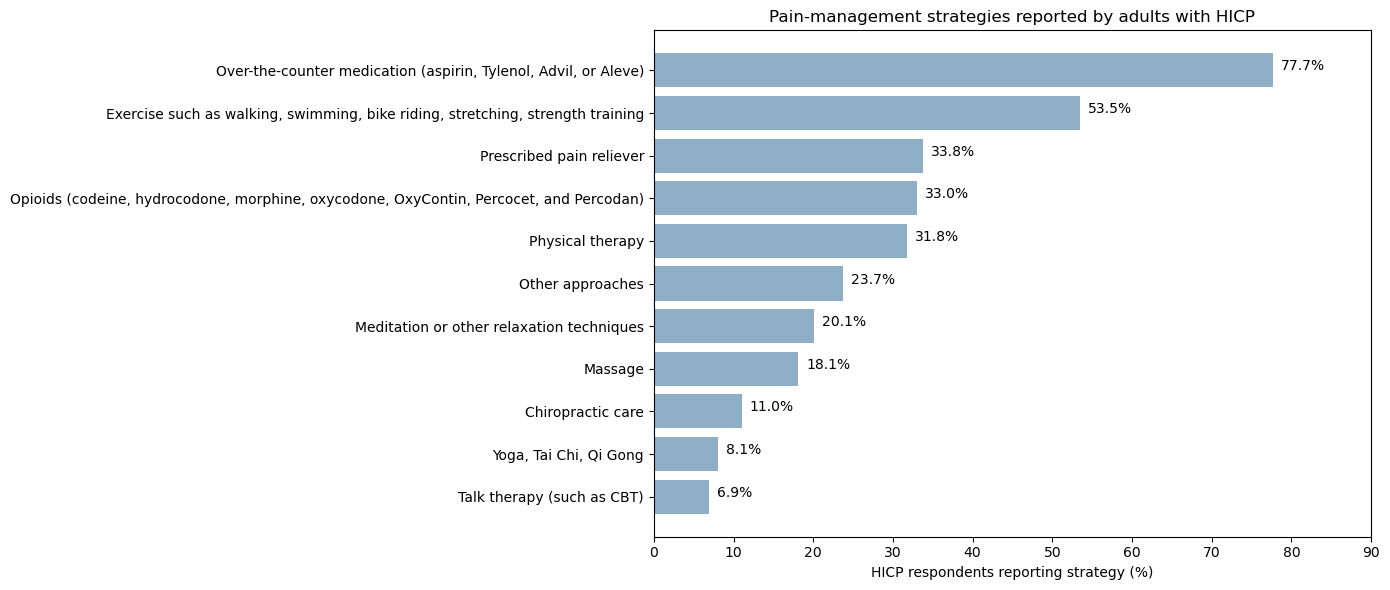

In [11]:
plt.figure(figsize=(14, 6))

plt.barh(
    strategy_uptake["Strategy"],
    strategy_uptake["Percent"],
    color="#8FAFC7"
)

plt.xlabel("HICP respondents reporting strategy (%)")
plt.ylabel("")
plt.title("Pain-management strategies reported by adults with HICP")

plt.gca().invert_yaxis()

for i, value in enumerate(strategy_uptake["Percent"]):
    plt.text(value + 1, i, f"{value:.1f}%")

plt.xlim(0, 90)
plt.tight_layout()
plt.show()

## Grouping strategies by type

-> To get a better picture of pain management, I group the strategies into pharmacological and non-pharmacological approaches.

-> The three medication variables are considered pharmacological:

- over-the-counter medication
- opioids
- prescribed pain relievers

The remaining clearly identifiable strategies are considered non-pharmacological:

- physical therapy
- chiropractic care
- talk therapy
- yoga / Tai Chi / Qi Gong
- exercise
- massage
- meditation / relaxation

**PAIMOTHER_A** is not included in either group because the question only asks about "other approaches". It does not tell me what type of approach was used, so I cannot classify it as pharmacological or non-pharmacological.

In [12]:
pharmacological_vars = [
    "PAIOTCMEDS_A",
    "PAIOPIOID_A",
    "PAIPRSMEDS_A"
]

non_pharmacological_vars = [
    "PAIPHYSTPY_A",
    "PAICHIRO_A",
    "PAITALKTPY_A",
    "PAIYOGA_A",
    "PAIEXRCISE_A",
    "PAIMASSAGE_A",
    "PAIMEDITAT_A"
]

grouping_vars = pharmacological_vars + non_pharmacological_vars

In [13]:
valid_for_grouping = hicp_df[grouping_vars].isin([1, 2]).all(axis=1)

print("HICP sample:", len(hicp_df))
print("Valid for grouping:", valid_for_grouping.sum())
print("Excluded because of special responses:", (~valid_for_grouping).sum())

HICP sample: 1956
Valid for grouping: 1926
Excluded because of special responses: 30


In [14]:
print(f"{valid_for_grouping.sum()} out of {len(hicp_df)} "
      f"({valid_for_grouping.mean() * 100:.1f}%)")

1926 out of 1956 (98.5%)


-> Almost all HICP respondents can be used for this grouping: 1926 out of 1956 (98.5%).

-> The remaining 30 have at least one special response code across the 10 classifiable strategies, so I exclude them rather than treating an unknown response as a No.

In [15]:
grouping_df = hicp_df[valid_for_grouping].copy()

# People who answered Yes to none of the 10 classifiable strategies
no_classifiable_strategy = ((grouping_df[grouping_vars] == 1).sum(axis=1) == 0)

print("No classifiable strategy reported:", no_classifiable_strategy.sum())

No classifiable strategy reported: 59


In [16]:
grouping_df.loc[no_classifiable_strategy, "PAIMOTHER_A"].value_counts().sort_index()

PAIMOTHER_A
1.0    11
2.0    48
Name: count, dtype: int64

### Checking the "other approaches" problem

-> Among the 59 respondents who did not report any of the 10 classifiable strategies, 11 still reported using an "other approach" (1=yes).

-> This means I cannot automatically treat everyone with no classifiable strategy as using neither type of pain management.

-> Before defining the final groups, I also check whether "other approaches" appear among people who would otherwise be classified as pharmacological only or non-pharmacological only.

In [17]:
grouping_df["has_pharmacological"] = (grouping_df[pharmacological_vars] == 1).any(axis=1)

grouping_df["has_non_pharmacological"] = (grouping_df[non_pharmacological_vars] == 1).any(axis=1)

In [18]:
grouping_df["preliminary_group"] = "Neither"

grouping_df.loc[grouping_df["has_pharmacological"] & ~grouping_df["has_non_pharmacological"], "preliminary_group"] = "Pharmacological only"

grouping_df.loc[~grouping_df["has_pharmacological"] & grouping_df["has_non_pharmacological"],"preliminary_group"] = "Non-pharmacological only"

grouping_df.loc[grouping_df["has_pharmacological"] & grouping_df["has_non_pharmacological"],"preliminary_group"] = "Both"

In [19]:
pd.crosstab(grouping_df["preliminary_group"],grouping_df["PAIMOTHER_A"])

PAIMOTHER_A,1.0,2.0
preliminary_group,,
Both,343,917
Neither,11,48
Non-pharmacological only,24,106
Pharmacological only,78,399


### Quick note on the grouping

-> I first checked whether each person had at least one pharmacological strategy and/or at least one non-pharmacological strategy.

-> That gives 4 groups:

- both
- pharmacological only
- non-pharmacological only
- neither

-> Then I checked for PAIMOTHER_A inside those groups, just to see where the "other approaches" answers were appearing.

-> They appear in all 4 groups (343 in both, 78 in pharmacological only, 24 in non-pharmacological only and 11 in neither).

> **So PAIMOTHER_A is not being used to define the groups. I am only using the 10 strategies that I can actually classify as pharmacological or non-pharmacological.**

-> This means that "both", "pharmacological only", "non-pharmacological only" and "neither" refer only to the 10 strategies that I can actually classify, not necessarily to every pain-management approach a person may have used.

In [20]:
grouping_df["strategy_group"] = grouping_df["preliminary_group"]

group_summary = grouping_df["strategy_group"].value_counts().to_frame("n")

group_summary["Percent"] = (group_summary["n"] / len(grouping_df) * 100).round(1)

group_summary

,n,Percent
strategy_group,,
Both,1260,65.4
Pharmacological only,477,24.8
Non-pharmacological only,130,6.7
Neither,59,3.1


### What stands out??

-> Most respondents **(65.4%)** report using **both pharmacological and non-pharmacological strategies** for pain management.

-> Around one quarter (24.8%) report pharmacological strategies only, while 6.7% report non-pharmacological strategies only.

-> Only 3.1% fall into the "neither" group.

*NOTE*: These groups are based only on the 10 strategies that could be clearly classified as pharmacological or non-pharmacological.
-> PAIMOTHER_A` was analysed separately because "other approaches" cannot be assigned to either category. Among the 59 respondents classified as "neither", 11 still reported using an "other approach".

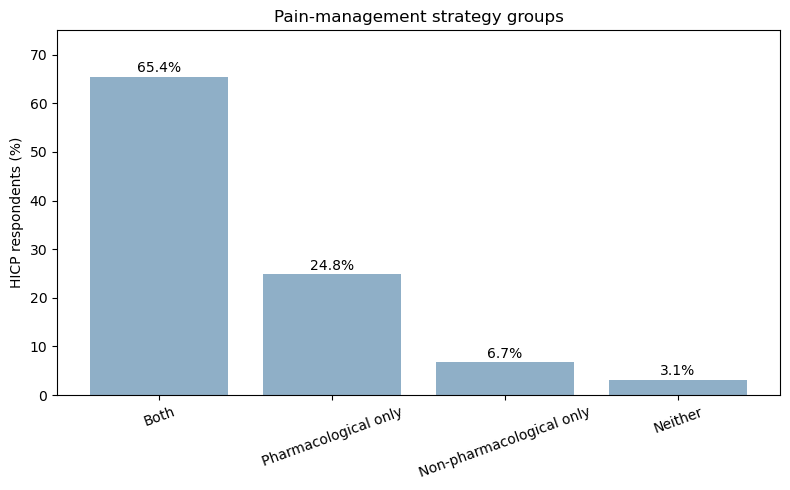

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    group_summary.index,
    group_summary["Percent"],
    color="#8FAFC7"
)

plt.ylabel("HICP respondents (%)")
plt.title("Pain-management strategy groups")

for i, value in enumerate(group_summary["Percent"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, 75)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()